In [ ]:
# ============================================================
# 10_AURORA_uncertainty_aware_mean_variance_allocation.ipynb
# AURORA-TWETF Uncertainty-Aware Mean-Variance Allocation
#
# Corrected version:
# - Fixes diagnostic DataFrame duplicate-column insertion error.
# - Uses safe metadata overwrite for diagnostics.
# - Uses purged walk-forward probabilities from Notebook 07.
# - Uses benchmarks from Notebook 08.
# - Compares UAMV against strong aligned benchmark set.
#
# Educational/research backtest only.
# Not personalized financial advice.
# ============================================================

from __future__ import annotations

import json
import math
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone

warnings.filterwarnings("ignore")

# ============================================================
# 0. Colab setup
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Google Drive mount skipped or failed.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy.optimize import minimize
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False
    print("scipy.optimize not available. Optimizer will use fallback allocations.")

# ============================================================
# 1. Paths and run configuration
# ============================================================

PROJECT_CODE = "AURORA_TWETF"
PUBLICATION_ROOT = Path("/content/drive/MyDrive/AURORA_TWETF")

DATA_ROOT = PUBLICATION_ROOT / "data"
PANEL_DIR = DATA_ROOT / "panels"
MODELING_DIR = DATA_ROOT / "modeling"

OUTPUT_ROOT = PUBLICATION_ROOT / "outputs" / PROJECT_CODE
TABLE_DIR = OUTPUT_ROOT / "tables"
REPORT_DIR = OUTPUT_ROOT / "reports"
FIGURE_DIR = OUTPUT_ROOT / "figures"

NOTEBOOK07_RUN_ID = "20260624_031817"
NOTEBOOK08_RUN_ID = "20260624_034204"
NOTEBOOK08B_RUN_ID = "20260624_070827"
NOTEBOOK09_RUN_ID = "20260624_072914"

NOTEBOOK07_ROOT = OUTPUT_ROOT / "purged_walk_forward_models" / f"run_{NOTEBOOK07_RUN_ID}"
NOTEBOOK08_ROOT = OUTPUT_ROOT / "stronger_financial_baselines_purged_allocation" / f"run_{NOTEBOOK08_RUN_ID}"
NOTEBOOK08B_ROOT = OUTPUT_ROOT / "aligned_oos_reanalysis" / f"run_{NOTEBOOK08B_RUN_ID}"
NOTEBOOK09_ROOT = OUTPUT_ROOT / "validation_optimized_regime_templates" / f"run_{NOTEBOOK09_RUN_ID}"

NOTEBOOK08_INPUT_INDEX = NOTEBOOK07_ROOT / "NOTEBOOK08_OR_ALLOCATION_INPUT_INDEX_PURGED_WF.csv"
NOTEBOOK08_WEIGHT_DIR = NOTEBOOK08_ROOT / "weights"
NOTEBOOK08_POLICY_DESCRIPTION_PATH = NOTEBOOK08_ROOT / "tables" / "policy_descriptions.csv"

RUN_TIMESTAMP = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

RUN_ROOT = OUTPUT_ROOT / "uncertainty_aware_mean_variance_allocation" / f"run_{RUN_ID}"

WEIGHT_DIR = RUN_ROOT / "weights"
RETURN_DIR = RUN_ROOT / "returns"
PLOT_DIR = RUN_ROOT / "plots"
TABLE_RUN_DIR = RUN_ROOT / "tables"
REPORT_RUN_DIR = RUN_ROOT / "reports"
DIAGNOSTIC_DIR = RUN_ROOT / "diagnostics"
PAPER_FIGURE_DIR = RUN_ROOT / "paper_figures"

for d in [
    OUTPUT_ROOT,
    TABLE_DIR,
    REPORT_DIR,
    FIGURE_DIR,
    RUN_ROOT,
    WEIGHT_DIR,
    RETURN_DIR,
    PLOT_DIR,
    TABLE_RUN_DIR,
    REPORT_RUN_DIR,
    DIAGNOSTIC_DIR,
    PAPER_FIGURE_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("AURORA-TWETF Notebook 10: Uncertainty-Aware Mean-Variance Allocation")
print("=" * 80)
print("Timestamp UTC       :", RUN_TIMESTAMP)
print("Run ID              :", RUN_ID)
print("Notebook 07 root    :", NOTEBOOK07_ROOT)
print("Notebook 08 root    :", NOTEBOOK08_ROOT)
print("Notebook 08B root   :", NOTEBOOK08B_ROOT)
print("Notebook 09 root    :", NOTEBOOK09_ROOT)
print("Notebook 08 registry:", NOTEBOOK08_INPUT_INDEX)
print("Run root            :", RUN_ROOT)
print("=" * 80)

for required_path in [
    NOTEBOOK07_ROOT,
    NOTEBOOK08_ROOT,
    NOTEBOOK08_INPUT_INDEX,
    NOTEBOOK08_WEIGHT_DIR,
    NOTEBOOK08_POLICY_DESCRIPTION_PATH,
]:
    if not Path(required_path).exists():
        raise FileNotFoundError(f"Required path not found: {required_path}")

# ============================================================
# 2. Global settings
# ============================================================

ETF_UNIVERSE = ["0050", "006208", "00692", "00881"]
CASH_COL = "CASH"
ALL_ASSETS = ETF_UNIVERSE + [CASH_COL]

CLASS_LABELS = [0, 1, 2, 3, 4]

REGIME_LABELS = {
    0: "Strong Bear",
    1: "Bear",
    2: "Neutral",
    3: "Bull",
    4: "Strong Bull",
}

ANNUALIZATION_DAYS = 252
INITIAL_CAPITAL = 1.0

TRANSACTION_COST_RATE = 0.0010
REBALANCE_FREQUENCY = "monthly"

RANDOM_STATE = 42

UAMV_CONFIGS = [
    {
        "strategy_name": "UAMV_A_balanced",
        "alpha_20d": 0.60,
        "alpha_60d": 0.40,
        "lookback_mu": 63,
        "lookback_cov": 126,
        "mean_shrinkage_to_zero": 0.50,
        "momentum_weight": 0.50,
        "base_risk_aversion": 8.0,
        "uncertainty_risk_multiplier": 2.0,
        "bearish_risk_multiplier": 1.5,
        "turnover_penalty": 0.20,
        "regime_tilt_strength": 0.35,
        "max_etf_weight": 0.45,
        "max_00881_weight": 0.35,
        "max_cash_weight": 0.50,
        "min_cash_weight": 0.00,
    },
    {
        "strategy_name": "UAMV_B_more60_defensive",
        "alpha_20d": 0.30,
        "alpha_60d": 0.70,
        "lookback_mu": 63,
        "lookback_cov": 126,
        "mean_shrinkage_to_zero": 0.60,
        "momentum_weight": 0.40,
        "base_risk_aversion": 10.0,
        "uncertainty_risk_multiplier": 2.5,
        "bearish_risk_multiplier": 2.0,
        "turnover_penalty": 0.25,
        "regime_tilt_strength": 0.25,
        "max_etf_weight": 0.45,
        "max_00881_weight": 0.30,
        "max_cash_weight": 0.60,
        "min_cash_weight": 0.00,
    },
    {
        "strategy_name": "UAMV_C_more60_growth",
        "alpha_20d": 0.30,
        "alpha_60d": 0.70,
        "lookback_mu": 63,
        "lookback_cov": 126,
        "mean_shrinkage_to_zero": 0.40,
        "momentum_weight": 0.60,
        "base_risk_aversion": 6.0,
        "uncertainty_risk_multiplier": 1.5,
        "bearish_risk_multiplier": 1.2,
        "turnover_penalty": 0.15,
        "regime_tilt_strength": 0.45,
        "max_etf_weight": 0.50,
        "max_00881_weight": 0.40,
        "max_cash_weight": 0.40,
        "min_cash_weight": 0.00,
    },
    {
        "strategy_name": "UAMV_D_low_turnover",
        "alpha_20d": 0.50,
        "alpha_60d": 0.50,
        "lookback_mu": 126,
        "lookback_cov": 252,
        "mean_shrinkage_to_zero": 0.60,
        "momentum_weight": 0.35,
        "base_risk_aversion": 9.0,
        "uncertainty_risk_multiplier": 2.0,
        "bearish_risk_multiplier": 1.5,
        "turnover_penalty": 0.50,
        "regime_tilt_strength": 0.25,
        "max_etf_weight": 0.45,
        "max_00881_weight": 0.35,
        "max_cash_weight": 0.50,
        "min_cash_weight": 0.00,
    },
    {
        "strategy_name": "UAMV_E_no_regime_tilt_control",
        "alpha_20d": 0.50,
        "alpha_60d": 0.50,
        "lookback_mu": 63,
        "lookback_cov": 126,
        "mean_shrinkage_to_zero": 0.50,
        "momentum_weight": 0.50,
        "base_risk_aversion": 8.0,
        "uncertainty_risk_multiplier": 0.0,
        "bearish_risk_multiplier": 0.0,
        "turnover_penalty": 0.20,
        "regime_tilt_strength": 0.00,
        "max_etf_weight": 0.45,
        "max_00881_weight": 0.35,
        "max_cash_weight": 0.50,
        "min_cash_weight": 0.00,
    },
]

SELECTION_OBJECTIVE_WEIGHTS = {
    "annual_return": 1.00,
    "annual_volatility": -0.10,
    "max_drawdown_abs": -0.25,
    "turnover": -0.03,
}

FALLBACK_CONSTRAINED_EQUAL = {
    "0050": 0.30,
    "006208": 0.30,
    "00692": 0.25,
    "00881": 0.15,
    "CASH": 0.00,
}

FALLBACK_DEFENSIVE = {
    "0050": 0.24,
    "006208": 0.24,
    "00692": 0.20,
    "00881": 0.12,
    "CASH": 0.20,
}

# ============================================================
# 3. Utility functions
# ============================================================

def save_json(path, obj):
    Path(path).write_text(
        json.dumps(obj, indent=2, ensure_ascii=False, default=str),
        encoding="utf-8",
    )

def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

def make_file_manifest(root):
    root = Path(root)
    rows = []

    for p in sorted(root.rglob("*")):
        if p.is_file():
            stat = p.stat()
            rows.append({
                "path": p.relative_to(root).as_posix(),
                "size_bytes": int(stat.st_size),
                "modified_utc": datetime.fromtimestamp(
                    stat.st_mtime,
                    timezone.utc,
                ).strftime("%Y-%m-%dT%H:%M:%SZ"),
                "sha256": sha256_file(p),
            })

    return pd.DataFrame(rows)

def safe_name(x):
    return (
        str(x)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace(" ", "_")
        .replace(".", "_")
    )

def clean_symbol_name(x):
    x = str(x)
    x = x.replace(".TW", "")
    x = x.replace(".TWO", "")
    x = x.replace("TW_", "")
    return x

def find_first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

def read_table_auto(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    if path.suffix.lower() == ".parquet":
        df = pd.read_parquet(path)
    elif path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported file type: {path}")

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.set_index("date")
    else:
        try:
            df.index = pd.to_datetime(df.index)
        except Exception:
            pass

    df.index.name = "date"
    return df.sort_index()

def load_etf_return_panel():
    candidates = [
        PANEL_DIR / "AURORA_etf_return_panel.parquet",
        PANEL_DIR / "AURORA_etf_returns_panel.parquet",
        PANEL_DIR / "AURORA_return_panel.parquet",
        MODELING_DIR / "AURORA_etf_return_panel.parquet",
    ]

    path = find_first_existing(candidates)

    if path is None:
        raise FileNotFoundError(
            "Could not find ETF return panel. Tried:\n"
            + "\n".join(str(p) for p in candidates)
        )

    df = pd.read_parquet(path)
    df.index = pd.to_datetime(df.index)
    df.index.name = "date"
    df = df.sort_index()
    df = df.rename(columns={c: clean_symbol_name(c) for c in df.columns})

    missing = [s for s in ETF_UNIVERSE if s not in df.columns]
    if missing:
        raise ValueError(
            f"ETF return panel found at {path}, but missing ETF columns: {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

    df = df[ETF_UNIVERSE].copy()
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return df, path

def normalize_rows(df):
    out = df.copy()
    out = out.reindex(columns=ALL_ASSETS).fillna(0.0)
    out = out.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    out[out < 0] = 0.0

    row_sums = out.sum(axis=1)
    zero_mask = row_sums <= 0

    if zero_mask.any():
        out.loc[zero_mask, ETF_UNIVERSE] = 1.0 / len(ETF_UNIVERSE)
        out.loc[zero_mask, CASH_COL] = 0.0
        row_sums = out.sum(axis=1)

    out = out.div(row_sums, axis=0)
    return out

def normalize_vector(w):
    w = pd.Series(w, index=ALL_ASSETS, dtype=float)
    w = w.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    w[w < 0] = 0.0

    if w.sum() <= 0:
        w = pd.Series(FALLBACK_CONSTRAINED_EQUAL, dtype=float).reindex(ALL_ASSETS).fillna(0.0)

    w = w / w.sum()
    return w

def normalize_proba(p):
    p = np.asarray(p, dtype=float)
    p = np.nan_to_num(p, nan=0.0, posinf=0.0, neginf=0.0)
    p[p < 0] = 0.0

    row_sums = p.sum(axis=1, keepdims=True)
    zero_rows = row_sums[:, 0] <= 0

    if np.any(zero_rows):
        p[zero_rows, :] = 1.0 / p.shape[1]
        row_sums = p.sum(axis=1, keepdims=True)

    return p / row_sums

def proba_cols():
    return [f"proba_class_{i}" for i in CLASS_LABELS]

def latest_fold_deduplicate(proba_df, split_filter=None):
    df = proba_df.copy()

    if split_filter is not None and "split" in df.columns:
        if isinstance(split_filter, str):
            split_filter = [split_filter]
        df = df[df["split"].isin(split_filter)].copy()

    if df.empty:
        return df

    df = df.reset_index()

    if "fold_id" not in df.columns:
        df["fold_id"] = "WF0"

    df["fold_number"] = (
        df["fold_id"]
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .fillna("0")
        .astype(int)
    )

    split_priority = {"train": 0, "validation": 1, "test": 2}
    if "split" in df.columns:
        df["split_priority"] = df["split"].map(split_priority).fillna(0).astype(int)
    else:
        df["split_priority"] = 0

    df = df.sort_values(["date", "split_priority", "fold_number"])
    df = df.drop_duplicates(subset=["date"], keep="last")
    df = df.set_index("date").sort_index()
    df.index.name = "date"

    return df.drop(columns=["fold_number", "split_priority"], errors="ignore")

def add_diag_metadata(diag_df, policy_name, fold_id, strategy_name, period):
    out = diag_df.copy()

    out["policy_name"] = policy_name
    out["fold_id"] = fold_id
    out["strategy_name"] = strategy_name
    out["period"] = period

    front_cols = ["policy_name", "fold_id", "strategy_name", "period"]
    other_cols = [c for c in out.columns if c not in front_cols]

    return out[front_cols + other_cols]

def probability_features_from_blend(p20, p60, config):
    common = p20.index.intersection(p60.index).sort_values()

    p20 = p20.loc[common].copy()
    p60 = p60.loc[common].copy()

    prob20 = normalize_proba(p20[proba_cols()].values)
    prob60 = normalize_proba(p60[proba_cols()].values)

    alpha20 = float(config["alpha_20d"])
    alpha60 = float(config["alpha_60d"])

    if alpha20 + alpha60 <= 0:
        alpha20, alpha60 = 0.5, 0.5
    else:
        s = alpha20 + alpha60
        alpha20, alpha60 = alpha20 / s, alpha60 / s

    prob = alpha20 * prob20 + alpha60 * prob60
    prob = normalize_proba(prob)

    class_values = np.asarray(CLASS_LABELS, dtype=float)
    expected_class = prob @ class_values

    entropy = -np.sum(
        np.clip(prob, 1e-12, 1.0) * np.log(np.clip(prob, 1e-12, 1.0)),
        axis=1,
    )
    normalized_entropy = entropy / np.log(len(CLASS_LABELS))
    confidence = 1.0 - normalized_entropy

    sorted_p = np.sort(prob, axis=1)
    margin = sorted_p[:, -1] - sorted_p[:, -2]
    ordinal_variance = (prob @ (class_values ** 2)) - expected_class ** 2

    out = pd.DataFrame(index=common)
    out["expected_class"] = expected_class
    out["entropy"] = entropy
    out["normalized_entropy"] = normalized_entropy
    out["confidence_score"] = confidence
    out["probability_margin"] = margin
    out["ordinal_variance"] = ordinal_variance
    out["p_strong_bear"] = prob[:, 0]
    out["p_bear"] = prob[:, 1]
    out["p_neutral"] = prob[:, 2]
    out["p_bull"] = prob[:, 3]
    out["p_strong_bull"] = prob[:, 4]
    out["p_bearish"] = prob[:, 0] + prob[:, 1]
    out["p_bullish"] = prob[:, 3] + prob[:, 4]
    out["risk_on_score"] = (expected_class - 2.0) / 2.0

    for i, label in enumerate(CLASS_LABELS):
        out[f"proba_class_{label}"] = prob[:, i]

    return out

# ============================================================
# 4. Optimizer functions
# ============================================================

def apply_caps_to_vector(w, config):
    w = normalize_vector(w)

    max_etf_weight = float(config["max_etf_weight"])
    max_00881_weight = float(config["max_00881_weight"])
    max_cash_weight = float(config["max_cash_weight"])
    min_cash_weight = float(config["min_cash_weight"])

    w[CASH_COL] = min(max(w[CASH_COL], min_cash_weight), max_cash_weight)

    for etf in ETF_UNIVERSE:
        cap = max_etf_weight
        if etf == "00881":
            cap = min(cap, max_00881_weight)
        w[etf] = min(w[etf], cap)

    if w.sum() <= 0:
        w = pd.Series(FALLBACK_CONSTRAINED_EQUAL, dtype=float).reindex(ALL_ASSETS).fillna(0.0)

    w = w / w.sum()

    for _ in range(10):
        excess = 0.0
        capped = []

        for etf in ETF_UNIVERSE:
            cap = max_etf_weight
            if etf == "00881":
                cap = min(cap, max_00881_weight)

            if w[etf] > cap:
                excess += w[etf] - cap
                w[etf] = cap
                capped.append(etf)

        if w[CASH_COL] > max_cash_weight:
            excess += w[CASH_COL] - max_cash_weight
            w[CASH_COL] = max_cash_weight
            capped.append(CASH_COL)

        if w[CASH_COL] < min_cash_weight:
            needed = min_cash_weight - w[CASH_COL]
            w[CASH_COL] = min_cash_weight
            risky_sum = w[ETF_UNIVERSE].sum()
            if risky_sum > 0:
                w[ETF_UNIVERSE] *= max(0.0, risky_sum - needed) / risky_sum

        if excess <= 1e-12:
            break

        eligible = []
        for asset in ALL_ASSETS:
            if asset in capped:
                continue

            if asset == CASH_COL:
                if w[asset] < max_cash_weight:
                    eligible.append(asset)
            elif asset == "00881":
                if w[asset] < min(max_etf_weight, max_00881_weight):
                    eligible.append(asset)
            else:
                if w[asset] < max_etf_weight:
                    eligible.append(asset)

        if not eligible:
            break

        eligible_sum = w[eligible].sum()

        if eligible_sum <= 0:
            for asset in eligible:
                w[asset] += excess / len(eligible)
        else:
            w[eligible] += excess * (w[eligible] / eligible_sum)

        w = w.clip(lower=0.0)
        w = w / w.sum()

    return normalize_vector(w)

def fallback_weight(features_row, config):
    p_bearish = float(features_row.get("p_bearish", 0.0))
    confidence = float(features_row.get("confidence_score", 0.5))

    if p_bearish > 0.45 and confidence > 0.25:
        base = pd.Series(FALLBACK_DEFENSIVE, dtype=float)
    else:
        base = pd.Series(FALLBACK_CONSTRAINED_EQUAL, dtype=float)

    return apply_caps_to_vector(base.reindex(ALL_ASSETS).fillna(0.0), config)

def estimate_moments_for_date(etf_returns, date, features_row, config):
    lookback_mu = int(config["lookback_mu"])
    lookback_cov = int(config["lookback_cov"])

    hist_all = etf_returns.loc[etf_returns.index < date, ETF_UNIVERSE].copy()

    if len(hist_all) < max(30, min(lookback_mu, lookback_cov) // 2):
        return None, None

    hist_mu = hist_all.tail(lookback_mu)
    hist_cov = hist_all.tail(lookback_cov)

    if len(hist_mu) < 20 or len(hist_cov) < 30:
        return None, None

    mean_short = hist_mu.mean().values
    momentum_return = (1.0 + hist_mu).prod().values - 1.0
    momentum_daily = momentum_return / max(len(hist_mu), 1)

    momentum_weight = float(config["momentum_weight"])
    shrink = float(config["mean_shrinkage_to_zero"])

    mu_risky = (
        (1.0 - momentum_weight) * mean_short
        + momentum_weight * momentum_daily
    )

    mu_risky = (1.0 - shrink) * mu_risky

    risk_on = float(features_row.get("risk_on_score", 0.0))
    p_bearish = float(features_row.get("p_bearish", 0.0))
    p_bullish = float(features_row.get("p_bullish", 0.0))

    tilt_strength = float(config["regime_tilt_strength"])

    tilt = pd.Series(0.0, index=ETF_UNIVERSE)
    tilt["0050"] += 0.15 * risk_on
    tilt["006208"] += 0.15 * risk_on
    tilt["00692"] += 0.05 * risk_on
    tilt["00881"] += 0.35 * risk_on + 0.15 * p_bullish - 0.20 * p_bearish
    tilt["00692"] += 0.10 * p_bearish

    realized_vol = hist_cov.std().replace(0.0, np.nan)
    vol_scale = realized_vol.median()

    if not np.isfinite(vol_scale) or vol_scale <= 0:
        vol_scale = 0.01

    mu_risky = mu_risky + tilt_strength * tilt.values * vol_scale / ANNUALIZATION_DAYS

    cov_risky = hist_cov.cov().values
    cov_risky = np.nan_to_num(cov_risky, nan=0.0, posinf=0.0, neginf=0.0)

    avg_var = np.mean(np.diag(cov_risky))
    if not np.isfinite(avg_var) or avg_var <= 0:
        avg_var = 1e-4

    cov_risky = cov_risky + np.eye(len(ETF_UNIVERSE)) * avg_var * 0.10

    mu = np.zeros(len(ALL_ASSETS), dtype=float)
    mu[:len(ETF_UNIVERSE)] = mu_risky
    mu[-1] = 0.0

    cov = np.zeros((len(ALL_ASSETS), len(ALL_ASSETS)), dtype=float)
    cov[:len(ETF_UNIVERSE), :len(ETF_UNIVERSE)] = cov_risky
    cov[-1, -1] = 1e-10

    return mu, cov

def risk_aversion_for_date(features_row, config):
    base = float(config["base_risk_aversion"])
    uncertainty_mult = float(config["uncertainty_risk_multiplier"])
    bearish_mult = float(config["bearish_risk_multiplier"])

    uncertainty = float(features_row.get("normalized_entropy", 0.5))
    p_bearish = float(features_row.get("p_bearish", 0.0))

    lam = base * (1.0 + uncertainty_mult * uncertainty + bearish_mult * p_bearish)
    return float(max(lam, 1e-6))

def optimize_single_date(mu, cov, prev_w, features_row, config):
    if mu is None or cov is None or not HAS_SCIPY:
        return fallback_weight(features_row, config), "fallback_no_moments_or_scipy"

    max_etf_weight = float(config["max_etf_weight"])
    max_00881_weight = float(config["max_00881_weight"])
    max_cash_weight = float(config["max_cash_weight"])
    min_cash_weight = float(config["min_cash_weight"])
    turnover_penalty = float(config["turnover_penalty"])

    lam = risk_aversion_for_date(features_row, config)
    prev = normalize_vector(prev_w).values

    bounds = []
    for asset in ALL_ASSETS:
        if asset == CASH_COL:
            bounds.append((min_cash_weight, max_cash_weight))
        elif asset == "00881":
            bounds.append((0.0, min(max_etf_weight, max_00881_weight)))
        else:
            bounds.append((0.0, max_etf_weight))

    def objective(w):
        w = np.asarray(w, dtype=float)
        expected_return = float(mu @ w)
        variance = float(w.T @ cov @ w)
        turnover_term = float(np.sum((w - prev) ** 2))
        utility = expected_return - lam * variance - turnover_penalty * turnover_term
        return -utility

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    x0 = apply_caps_to_vector(prev, config).values

    try:
        res = minimize(
            objective,
            x0=x0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"maxiter": 300, "ftol": 1e-10, "disp": False},
        )

        if res.success and np.all(np.isfinite(res.x)):
            w = apply_caps_to_vector(res.x, config)
            return w, "optimized"

        w = fallback_weight(features_row, config)
        return w, f"fallback_optimizer_failed_{str(res.message)[:80]}"

    except Exception as e:
        w = fallback_weight(features_row, config)
        return w, f"fallback_exception_{repr(e)[:80]}"

def build_uamv_signal_weights(p20, p60, etf_returns, config, evaluation_dates):
    features = probability_features_from_blend(p20, p60, config)

    evaluation_dates = (
        pd.DatetimeIndex(evaluation_dates)
        .intersection(features.index)
        .intersection(etf_returns.index)
        .sort_values()
    )

    if len(evaluation_dates) == 0:
        raise ValueError(f"No evaluation dates for {config['strategy_name']}")

    rows = []
    diagnostics = []

    prev_w = pd.Series(FALLBACK_CONSTRAINED_EQUAL, dtype=float).reindex(ALL_ASSETS).fillna(0.0)
    prev_w = apply_caps_to_vector(prev_w, config)

    for dt in evaluation_dates:
        features_row = features.loc[dt]

        mu, cov = estimate_moments_for_date(
            etf_returns=etf_returns,
            date=dt,
            features_row=features_row,
            config=config,
        )

        w, status = optimize_single_date(
            mu=mu,
            cov=cov,
            prev_w=prev_w,
            features_row=features_row,
            config=config,
        )

        rows.append(w.values)

        diag = {
            "date": dt,
            "strategy_name": config["strategy_name"],
            "optimization_status": status,
            "risk_aversion": risk_aversion_for_date(features_row, config),
            "expected_class": float(features_row["expected_class"]),
            "p_bearish": float(features_row["p_bearish"]),
            "p_bullish": float(features_row["p_bullish"]),
            "normalized_entropy": float(features_row["normalized_entropy"]),
            "confidence_score": float(features_row["confidence_score"]),
            "ordinal_variance": float(features_row["ordinal_variance"]),
        }

        if mu is not None and cov is not None:
            diag["estimated_mu_0050"] = float(mu[ALL_ASSETS.index("0050")])
            diag["estimated_mu_006208"] = float(mu[ALL_ASSETS.index("006208")])
            diag["estimated_mu_00692"] = float(mu[ALL_ASSETS.index("00692")])
            diag["estimated_mu_00881"] = float(mu[ALL_ASSETS.index("00881")])
            diag["estimated_portfolio_mu"] = float(mu @ w.values)
            diag["estimated_portfolio_vol_daily"] = float(math.sqrt(max(w.values.T @ cov @ w.values, 0.0)))
        else:
            diag["estimated_mu_0050"] = np.nan
            diag["estimated_mu_006208"] = np.nan
            diag["estimated_mu_00692"] = np.nan
            diag["estimated_mu_00881"] = np.nan
            diag["estimated_portfolio_mu"] = np.nan
            diag["estimated_portfolio_vol_daily"] = np.nan

        diagnostics.append(diag)
        prev_w = w

    weight_df = pd.DataFrame(rows, index=evaluation_dates, columns=ALL_ASSETS)
    weight_df.index.name = "date"
    weight_df = normalize_rows(weight_df)

    diagnostic_df = pd.DataFrame(diagnostics).set_index("date").sort_index()
    diagnostic_df.index.name = "date"

    return weight_df, diagnostic_df

# ============================================================
# 5. Backtest functions
# ============================================================

def get_rebalance_dates(index, frequency):
    idx = pd.DatetimeIndex(index).sort_values()

    if frequency == "monthly":
        groups = pd.Series(idx, index=idx).groupby([idx.year, idx.month])
    elif frequency == "quarterly":
        groups = pd.Series(idx, index=idx).groupby([idx.year, idx.quarter])
    elif frequency == "weekly":
        iso = idx.isocalendar()
        groups = pd.Series(idx, index=idx).groupby([iso.year, iso.week])
    else:
        raise ValueError(f"Unsupported rebalance frequency: {frequency}")

    dates = []
    for _, values in groups:
        dates.append(values.iloc[0])

    return pd.DatetimeIndex(dates)

def expand_rebalance_weights_to_daily(signal_weight_df, daily_index, rebalance_dates):
    signal = signal_weight_df.reindex(columns=ALL_ASSETS).fillna(0.0).copy()
    signal = normalize_rows(signal)
    signal_idx = pd.DatetimeIndex(signal.index).sort_values()

    daily = pd.DataFrame(index=daily_index, columns=ALL_ASSETS, dtype=float)

    for i, reb_date in enumerate(rebalance_dates):
        if i + 1 < len(rebalance_dates):
            period_idx = daily_index[(daily_index >= reb_date) & (daily_index < rebalance_dates[i + 1])]
        else:
            period_idx = daily_index[daily_index >= reb_date]

        prior_signals = signal_idx[signal_idx < reb_date]

        if len(prior_signals) == 0:
            signal_date = signal_idx[0]
        else:
            signal_date = prior_signals[-1]

        daily.loc[period_idx, ALL_ASSETS] = signal.loc[signal_date, ALL_ASSETS].values

    daily = daily.ffill().bfill()
    daily = normalize_rows(daily)

    return daily

def compute_turnover(daily_weights, rebalance_dates):
    turnover = pd.Series(0.0, index=daily_weights.index)
    prev_w = None

    for dt in rebalance_dates:
        if dt not in daily_weights.index:
            continue

        w = daily_weights.loc[dt, ALL_ASSETS]

        if prev_w is None:
            turnover.loc[dt] = w.drop(labels=[CASH_COL], errors="ignore").abs().sum()
        else:
            turnover.loc[dt] = (w - prev_w).abs().sum() / 2.0

        prev_w = w

    return turnover

def backtest_on_fixed_index(policy_name, signal_weights, etf_returns, evaluation_index):
    evaluation_index = pd.DatetimeIndex(evaluation_index).sort_values()

    returns = etf_returns.copy()
    returns[CASH_COL] = 0.0
    returns = returns.reindex(evaluation_index)

    if returns[ALL_ASSETS].isna().any().any():
        missing_rows = returns[returns[ALL_ASSETS].isna().any(axis=1)]
        raise ValueError(
            f"Return panel has missing rows for {policy_name}. "
            f"Example missing dates: {missing_rows.index[:5].tolist()}"
        )

    signal = signal_weights.copy()
    signal.index = pd.to_datetime(signal.index)
    signal = signal.sort_index()
    signal = signal.reindex(columns=ALL_ASSETS).fillna(0.0)

    signal_aligned = signal.reindex(evaluation_index).ffill().bfill()
    signal_aligned = normalize_rows(signal_aligned)

    rebalance_dates = get_rebalance_dates(evaluation_index, REBALANCE_FREQUENCY)

    daily_weights = expand_rebalance_weights_to_daily(
        signal_weight_df=signal_aligned,
        daily_index=evaluation_index,
        rebalance_dates=rebalance_dates,
    )

    gross_return = (daily_weights[ALL_ASSETS] * returns[ALL_ASSETS]).sum(axis=1)
    turnover = compute_turnover(daily_weights, rebalance_dates)
    transaction_cost = turnover * TRANSACTION_COST_RATE
    net_return = gross_return - transaction_cost

    equity = (1.0 + net_return).cumprod() * INITIAL_CAPITAL

    out = pd.DataFrame(index=evaluation_index)
    out.index.name = "date"
    out["policy_name"] = policy_name
    out["gross_return"] = gross_return
    out["turnover"] = turnover
    out["transaction_cost"] = transaction_cost
    out["net_return"] = net_return
    out["equity"] = equity
    out["drawdown"] = equity / equity.cummax() - 1.0
    out["is_rebalance_date"] = out.index.isin(rebalance_dates)

    return out, daily_weights

def performance_metrics(return_df):
    r = return_df["net_return"].astype(float).copy()
    equity = return_df["equity"].astype(float).copy()
    drawdown = return_df["drawdown"].astype(float).copy()

    n = len(r)
    if n == 0:
        return {}

    total_return = float(equity.iloc[-1] / equity.iloc[0] - 1.0) if equity.iloc[0] != 0 else np.nan
    annual_return = float((1.0 + total_return) ** (ANNUALIZATION_DAYS / max(n, 1)) - 1.0)

    annual_vol = float(r.std(ddof=1) * np.sqrt(ANNUALIZATION_DAYS)) if n > 1 else np.nan
    sharpe = annual_return / annual_vol if annual_vol and annual_vol > 0 else np.nan

    downside = r[r < 0]
    downside_vol = float(downside.std(ddof=1) * np.sqrt(ANNUALIZATION_DAYS)) if len(downside) > 1 else np.nan
    sortino = annual_return / downside_vol if downside_vol and downside_vol > 0 else np.nan

    max_drawdown = float(drawdown.min())
    calmar = annual_return / abs(max_drawdown) if max_drawdown < 0 else np.nan

    return {
        "n_days": int(n),
        "start_date": str(r.index.min().date()),
        "end_date": str(r.index.max().date()),
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_volatility": annual_vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "max_drawdown": max_drawdown,
        "calmar_ratio": calmar,
        "hit_rate": float((r > 0).mean()),
        "avg_daily_return": float(r.mean()),
        "avg_turnover": float(return_df["turnover"].mean()),
        "total_turnover": float(return_df["turnover"].sum()),
        "total_transaction_cost": float(return_df["transaction_cost"].sum()),
        "final_equity": float(equity.iloc[-1]),
    }

def selection_objective(metrics):
    annual_return = float(metrics.get("annual_return", 0.0))
    annual_vol = float(metrics.get("annual_volatility", 0.0))
    max_dd_abs = abs(float(metrics.get("max_drawdown", 0.0)))
    turnover = float(metrics.get("total_turnover", 0.0))

    return float(
        SELECTION_OBJECTIVE_WEIGHTS["annual_return"] * annual_return
        + SELECTION_OBJECTIVE_WEIGHTS["annual_volatility"] * annual_vol
        + SELECTION_OBJECTIVE_WEIGHTS["max_drawdown_abs"] * max_dd_abs
        + SELECTION_OBJECTIVE_WEIGHTS["turnover"] * turnover
    )

def add_composite_rank(df):
    out = df.copy()

    out["rank_total_return"] = out["total_return"].rank(ascending=False, method="min")
    out["rank_sharpe"] = out["sharpe_ratio"].rank(ascending=False, method="min")
    out["rank_sortino"] = out["sortino_ratio"].rank(ascending=False, method="min")
    out["rank_drawdown"] = out["max_drawdown"].rank(ascending=False, method="min")
    out["rank_calmar"] = out["calmar_ratio"].rank(ascending=False, method="min")

    out["allocation_composite_rank"] = (
        out["rank_total_return"]
        + out["rank_sharpe"]
        + out["rank_sortino"]
        + out["rank_drawdown"]
        + out["rank_calmar"]
    ) / 5.0

    return out.sort_values(
        ["allocation_composite_rank", "sharpe_ratio", "total_return"],
        ascending=[True, False, False],
    )

# ============================================================
# 6. Plot functions
# ============================================================

def plot_metric_bar(df, metric, path, title, higher_is_better=True, top_n=25):
    tmp = df.copy()
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna(subset=[metric])
    tmp = tmp.sort_values(metric, ascending=not higher_is_better)

    if top_n is not None:
        tmp = tmp.head(top_n)

    plt.figure(figsize=(11, max(4, 0.4 * len(tmp))))
    sns.barplot(data=tmp, y="policy_name", x=metric, color="#4C72B0")
    plt.title(title)
    plt.xlabel(metric)
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(path, dpi=220)
    plt.close()

def plot_equity_curves(all_returns_df, path, title, rank_df=None, top_n=12):
    if rank_df is not None:
        policies = rank_df.head(top_n)["policy_name"].tolist()
    else:
        policies = (
            all_returns_df.groupby("policy_name")["equity"]
            .last()
            .sort_values(ascending=False)
            .head(top_n)
            .index
            .tolist()
        )

    plt.figure(figsize=(12, 6))
    for policy in policies:
        grp = all_returns_df[all_returns_df["policy_name"] == policy].sort_index()
        plt.plot(grp.index, grp["equity"], label=policy, linewidth=1.7)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity, initial capital = 1")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.savefig(path, dpi=220)
    plt.close()

def plot_drawdowns(all_returns_df, path, title, rank_df=None, top_n=12):
    if rank_df is not None:
        policies = rank_df.head(top_n)["policy_name"].tolist()
    else:
        policies = (
            all_returns_df.groupby("policy_name")["equity"]
            .last()
            .sort_values(ascending=False)
            .head(top_n)
            .index
            .tolist()
        )

    plt.figure(figsize=(12, 6))
    for policy in policies:
        grp = all_returns_df[all_returns_df["policy_name"] == policy].sort_index()
        plt.plot(grp.index, grp["drawdown"], label=policy, linewidth=1.5)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.savefig(path, dpi=220)
    plt.close()

def plot_weight_area(weight_df, policy_name, path):
    tmp = weight_df.copy()
    tmp = tmp.reindex(columns=ALL_ASSETS).fillna(0.0)

    plt.figure(figsize=(12, 6))
    plt.stackplot(
        tmp.index,
        [tmp[c].values for c in ALL_ASSETS],
        labels=ALL_ASSETS,
        alpha=0.85,
    )
    plt.title(f"Weights: {policy_name}")
    plt.xlabel("Date")
    plt.ylabel("Weight")
    plt.ylim(0, 1)
    plt.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig(path, dpi=220)
    plt.close()

# ============================================================
# 7. Load data and probability files
# ============================================================

print("\n" + "=" * 80)
print("Step 1: Loading ETF returns and Notebook 07 probabilities")
print("=" * 80)

etf_returns, etf_return_path = load_etf_return_panel()

print("ETF return panel:", etf_return_path)
print("ETF return shape:", etf_returns.shape)
print("ETF date range  :", etf_returns.index.min().date(), "to", etf_returns.index.max().date())

input_index_df = pd.read_csv(NOTEBOOK08_INPUT_INDEX)

p20_path = None
p60_path = None

for _, row in input_index_df.iterrows():
    target_col = row["target_col"]

    path = Path(row["probability_path_parquet"])
    if not path.exists():
        path = Path(row["probability_path_csv"])

    if "20d" in target_col:
        p20_path = path
    elif "60d" in target_col:
        p60_path = path

if p20_path is None or p60_path is None:
    raise ValueError("Could not locate both 20d and 60d probability files.")

p20_raw = read_table_auto(p20_path)
p60_raw = read_table_auto(p60_path)

print("20d probability file:", p20_path, p20_raw.shape)
print("60d probability file:", p60_path, p60_raw.shape)

for name, prob_df in [("p20_raw", p20_raw), ("p60_raw", p60_raw)]:
    missing = [c for c in proba_cols() if c not in prob_df.columns]
    if missing:
        raise ValueError(f"{name} missing probability columns: {missing}")

if "fold_id" not in p20_raw.columns or "fold_id" not in p60_raw.columns:
    raise ValueError("Probability files must include fold_id.")

if "split" not in p20_raw.columns or "split" not in p60_raw.columns:
    raise ValueError("Probability files must include split.")

fold_ids = sorted(set(p20_raw["fold_id"].unique()).intersection(set(p60_raw["fold_id"].unique())))
print("Common fold IDs:", fold_ids)

# ============================================================
# 8. Load benchmark weights
# ============================================================

print("\n" + "=" * 80)
print("Step 2: Loading Notebook 08 benchmark weights")
print("=" * 80)

policy_description_df = pd.read_csv(NOTEBOOK08_POLICY_DESCRIPTION_PATH)

benchmark_policy_rows = policy_description_df[
    policy_description_df["policy_type"].isin(["passive_benchmark", "dynamic_financial_baseline"])
].copy()

benchmark_weight_dict = {}
benchmark_type_dict = {}

for _, row in benchmark_policy_rows.iterrows():
    policy_name = row["policy_name"]
    policy_type = row["policy_type"]

    weight_path = NOTEBOOK08_WEIGHT_DIR / f"signal_weights_{safe_name(policy_name)}.parquet"

    if not weight_path.exists():
        weight_path = NOTEBOOK08_WEIGHT_DIR / f"signal_weights_{safe_name(policy_name)}.csv"

    if not weight_path.exists():
        print("WARNING: benchmark weight file missing:", policy_name)
        continue

    w = read_table_auto(weight_path)
    w = w.reindex(columns=ALL_ASSETS).fillna(0.0)
    w = normalize_rows(w)

    benchmark_weight_dict[policy_name] = w
    benchmark_type_dict[policy_name] = policy_type

print("Loaded benchmark weights:", len(benchmark_weight_dict))
print(pd.Series(benchmark_type_dict).value_counts().to_string())

# ============================================================
# 9. Fold-level validation and test evaluation
# ============================================================

print("\n" + "=" * 80)
print("Step 3: Running UAMV validation and test folds")
print("=" * 80)

fold_validation_rows = []
fold_test_rows = []
all_uamv_return_frames = []
all_uamv_weight_frames = []
all_uamv_diag_frames = []
fold_selected_rows = []

for fold_id in fold_ids:
    print("\n" + "-" * 80)
    print("Fold:", fold_id)
    print("-" * 80)

    p20_val = p20_raw[(p20_raw["fold_id"] == fold_id) & (p20_raw["split"] == "validation")].copy()
    p60_val = p60_raw[(p60_raw["fold_id"] == fold_id) & (p60_raw["split"] == "validation")].copy()

    p20_test = p20_raw[(p20_raw["fold_id"] == fold_id) & (p20_raw["split"] == "test")].copy()
    p60_test = p60_raw[(p60_raw["fold_id"] == fold_id) & (p60_raw["split"] == "test")].copy()

    val_dates = p20_val.index.intersection(p60_val.index).intersection(etf_returns.index).sort_values()
    test_dates = p20_test.index.intersection(p60_test.index).intersection(etf_returns.index).sort_values()

    p20_val = p20_val.loc[val_dates].copy()
    p60_val = p60_val.loc[val_dates].copy()
    p20_test = p20_test.loc[test_dates].copy()
    p60_test = p60_test.loc[test_dates].copy()

    print("Validation dates:", len(val_dates), val_dates.min().date(), "to", val_dates.max().date())
    print("Test dates      :", len(test_dates), test_dates.min().date(), "to", test_dates.max().date())

    fold_strategy_records = []

    for config in UAMV_CONFIGS:
        strategy_name = config["strategy_name"]
        print("Evaluating:", strategy_name)

        val_signal_w, val_diag = build_uamv_signal_weights(
            p20=p20_val,
            p60=p60_val,
            etf_returns=etf_returns,
            config=config,
            evaluation_dates=val_dates,
        )

        val_policy_name = f"AURORA10_{strategy_name}_fold_{fold_id}"

        val_returns, val_daily_w = backtest_on_fixed_index(
            policy_name=val_policy_name,
            signal_weights=val_signal_w,
            etf_returns=etf_returns,
            evaluation_index=val_dates,
        )

        val_metrics = performance_metrics(val_returns)
        val_obj = selection_objective(val_metrics)

        val_row = {
            "run_id": RUN_ID,
            "fold_id": fold_id,
            "strategy_name": strategy_name,
            "policy_name": val_policy_name,
            "policy_type": "AURORA_uncertainty_aware_mean_variance",
            "period": "fold_validation",
            "selection_objective": val_obj,
            **val_metrics,
        }
        fold_validation_rows.append(val_row)

        test_signal_w, test_diag = build_uamv_signal_weights(
            p20=p20_test,
            p60=p60_test,
            etf_returns=etf_returns,
            config=config,
            evaluation_dates=test_dates,
        )

        test_returns, test_daily_w = backtest_on_fixed_index(
            policy_name=val_policy_name,
            signal_weights=test_signal_w,
            etf_returns=etf_returns,
            evaluation_index=test_dates,
        )

        test_metrics = performance_metrics(test_returns)

        test_row = {
            "run_id": RUN_ID,
            "fold_id": fold_id,
            "strategy_name": strategy_name,
            "policy_name": val_policy_name,
            "policy_type": "AURORA_uncertainty_aware_mean_variance",
            "period": "fold_test_out_of_sample",
            "validation_selection_objective": val_obj,
            **test_metrics,
        }
        fold_test_rows.append(test_row)

        fold_strategy_records.append({
            "strategy_name": strategy_name,
            "policy_name": val_policy_name,
            "selection_objective": val_obj,
            "validation_sharpe": val_metrics["sharpe_ratio"],
            "validation_total_return": val_metrics["total_return"],
            "test_sharpe": test_metrics["sharpe_ratio"],
            "test_total_return": test_metrics["total_return"],
        })

        val_returns_out = val_returns.copy()
        val_returns_out["fold_id"] = fold_id
        val_returns_out["strategy_name"] = strategy_name
        val_returns_out["period"] = "fold_validation"
        all_uamv_return_frames.append(val_returns_out)

        test_returns_out = test_returns.copy()
        test_returns_out["fold_id"] = fold_id
        test_returns_out["strategy_name"] = strategy_name
        test_returns_out["period"] = "fold_test_out_of_sample"
        all_uamv_return_frames.append(test_returns_out)

        val_w_out = val_daily_w.copy()
        val_w_out.insert(0, "period", "fold_validation")
        val_w_out.insert(0, "strategy_name", strategy_name)
        val_w_out.insert(0, "fold_id", fold_id)
        val_w_out.insert(0, "policy_name", val_policy_name)
        all_uamv_weight_frames.append(val_w_out)

        test_w_out = test_daily_w.copy()
        test_w_out.insert(0, "period", "fold_test_out_of_sample")
        test_w_out.insert(0, "strategy_name", strategy_name)
        test_w_out.insert(0, "fold_id", fold_id)
        test_w_out.insert(0, "policy_name", val_policy_name)
        all_uamv_weight_frames.append(test_w_out)

        val_diag_out = add_diag_metadata(
            diag_df=val_diag,
            policy_name=val_policy_name,
            fold_id=fold_id,
            strategy_name=strategy_name,
            period="fold_validation",
        )
        all_uamv_diag_frames.append(val_diag_out)

        test_diag_out = add_diag_metadata(
            diag_df=test_diag,
            policy_name=val_policy_name,
            fold_id=fold_id,
            strategy_name=strategy_name,
            period="fold_test_out_of_sample",
        )
        all_uamv_diag_frames.append(test_diag_out)

        val_signal_w.to_parquet(WEIGHT_DIR / f"signal_weights_validation_{safe_name(val_policy_name)}.parquet")
        test_signal_w.to_parquet(WEIGHT_DIR / f"signal_weights_test_{safe_name(val_policy_name)}.parquet")

        print(
            f"  Val obj={val_obj:.4f}, "
            f"Val Sharpe={val_metrics['sharpe_ratio']:.4f}, "
            f"Test Sharpe={test_metrics['sharpe_ratio']:.4f}"
        )

    fold_strategy_df = pd.DataFrame(fold_strategy_records)
    selected = fold_strategy_df.sort_values("selection_objective", ascending=False).iloc[0]

    fold_selected_rows.append({
        "run_id": RUN_ID,
        "fold_id": fold_id,
        "selected_strategy_name": selected["strategy_name"],
        "selected_policy_name": selected["policy_name"],
        "selection_rule": "maximum_validation_selection_objective",
        "selection_objective": float(selected["selection_objective"]),
        "validation_sharpe": float(selected["validation_sharpe"]),
        "validation_total_return": float(selected["validation_total_return"]),
        "test_sharpe": float(selected["test_sharpe"]),
        "test_total_return": float(selected["test_total_return"]),
    })

    print(
        "Selected for fold:",
        selected["strategy_name"],
        "| validation objective:",
        selected["selection_objective"],
    )

fold_validation_df = pd.DataFrame(fold_validation_rows)
fold_test_df = pd.DataFrame(fold_test_rows)
fold_selected_df = pd.DataFrame(fold_selected_rows)

uamv_returns_df = pd.concat(all_uamv_return_frames, axis=0)
uamv_weights_df = pd.concat(all_uamv_weight_frames, axis=0)
uamv_diag_df = pd.concat(all_uamv_diag_frames, axis=0)

fold_validation_df.to_csv(TABLE_RUN_DIR / "fold_validation_metrics_uamv.csv", index=False)
fold_validation_df.to_csv(TABLE_DIR / f"table_87_fold_validation_metrics_uamv_{RUN_ID}.csv", index=False)

fold_test_df.to_csv(TABLE_RUN_DIR / "fold_test_metrics_uamv.csv", index=False)
fold_test_df.to_csv(TABLE_DIR / f"table_88_fold_test_metrics_uamv_{RUN_ID}.csv", index=False)

fold_selected_df.to_csv(TABLE_RUN_DIR / "fold_selected_uamv_strategies.csv", index=False)
fold_selected_df.to_csv(TABLE_DIR / f"table_89_fold_selected_uamv_strategies_{RUN_ID}.csv", index=False)

uamv_returns_df.to_parquet(RETURN_DIR / "uamv_returns_by_fold.parquet")
uamv_returns_df.to_csv(RETURN_DIR / "uamv_returns_by_fold.csv")

uamv_weights_df.to_parquet(WEIGHT_DIR / "uamv_weights_by_fold.parquet")
uamv_weights_df.to_csv(WEIGHT_DIR / "uamv_weights_by_fold.csv")

uamv_diag_df.to_parquet(DIAGNOSTIC_DIR / "uamv_optimization_diagnostics_by_fold.parquet")
uamv_diag_df.to_csv(DIAGNOSTIC_DIR / "uamv_optimization_diagnostics_by_fold.csv")

# ============================================================
# 10. Aggregate test performance
# ============================================================

print("\n" + "=" * 80)
print("Step 4: Aggregating UAMV test performance")
print("=" * 80)

def aggregate_latest_fold_returns(df, strategy_name):
    tmp = df[
        (df["period"] == "fold_test_out_of_sample")
        & (df["strategy_name"] == strategy_name)
    ].copy()

    tmp = tmp.sort_index().reset_index()
    tmp["fold_number"] = (
        tmp["fold_id"].astype(str).str.extract(r"(\d+)", expand=False).fillna("0").astype(int)
    )
    tmp = tmp.sort_values(["date", "fold_number"])
    tmp = tmp.drop_duplicates(subset=["date"], keep="last")
    tmp = tmp.set_index("date").sort_index()
    tmp.index.name = "date"

    tmp["policy_name"] = f"AURORA10_{strategy_name}"
    tmp["equity"] = (1.0 + tmp["net_return"]).cumprod()
    tmp["drawdown"] = tmp["equity"] / tmp["equity"].cummax() - 1.0

    return tmp

aggregate_test_rows = []
aggregate_return_frames = []

for config in UAMV_CONFIGS:
    strategy_name = config["strategy_name"]

    combined = aggregate_latest_fold_returns(uamv_returns_df, strategy_name)

    metrics = performance_metrics(combined)
    metrics.update({
        "run_id": RUN_ID,
        "strategy_name": strategy_name,
        "policy_name": f"AURORA10_{strategy_name}",
        "policy_type": "AURORA_uncertainty_aware_mean_variance",
        "period": "aggregate_test_latest_fold",
    })

    aggregate_test_rows.append(metrics)
    aggregate_return_frames.append(combined)

    combined.to_parquet(RETURN_DIR / f"aggregate_test_returns_{safe_name(strategy_name)}.parquet")
    combined.to_csv(RETURN_DIR / f"aggregate_test_returns_{safe_name(strategy_name)}.csv")

aggregate_test_df = pd.DataFrame(aggregate_test_rows)

aggregate_test_df.to_csv(TABLE_RUN_DIR / "aggregate_test_metrics_uamv.csv", index=False)
aggregate_test_df.to_csv(TABLE_DIR / f"table_90_aggregate_test_metrics_uamv_{RUN_ID}.csv", index=False)

print("Aggregate UAMV test metrics:")
print(
    aggregate_test_df[
        [
            "strategy_name",
            "n_days",
            "start_date",
            "end_date",
            "total_return",
            "annual_return",
            "annual_volatility",
            "sharpe_ratio",
            "sortino_ratio",
            "max_drawdown",
            "calmar_ratio",
            "final_equity",
        ]
    ].sort_values("sharpe_ratio", ascending=False).to_string(index=False)
)

# ============================================================
# 11. Validation-selected aggregate UAMV policy
# ============================================================

print("\n" + "=" * 80)
print("Step 5: Creating validation-selected aggregate UAMV policy")
print("=" * 80)

selected_return_frames = []

for _, row in fold_selected_df.iterrows():
    fold_id = row["fold_id"]
    strategy_name = row["selected_strategy_name"]

    tmp = uamv_returns_df[
        (uamv_returns_df["fold_id"] == fold_id)
        & (uamv_returns_df["strategy_name"] == strategy_name)
        & (uamv_returns_df["period"] == "fold_test_out_of_sample")
    ].copy()

    selected_return_frames.append(tmp)

selected_test_returns = pd.concat(selected_return_frames, axis=0)
selected_test_returns = selected_test_returns.sort_index().reset_index()
selected_test_returns["fold_number"] = (
    selected_test_returns["fold_id"].astype(str).str.extract(r"(\d+)", expand=False).fillna("0").astype(int)
)
selected_test_returns = selected_test_returns.sort_values(["date", "fold_number"])
selected_test_returns = selected_test_returns.drop_duplicates(subset=["date"], keep="last")
selected_test_returns = selected_test_returns.set_index("date").sort_index()
selected_test_returns.index.name = "date"

selected_policy_name = "AURORA10_validation_selected_UAMV"
selected_test_returns["policy_name"] = selected_policy_name
selected_test_returns["equity"] = (1.0 + selected_test_returns["net_return"]).cumprod()
selected_test_returns["drawdown"] = selected_test_returns["equity"] / selected_test_returns["equity"].cummax() - 1.0

selected_metrics = performance_metrics(selected_test_returns)
selected_metrics.update({
    "run_id": RUN_ID,
    "policy_name": selected_policy_name,
    "strategy_name": "fold_validation_selected",
    "policy_type": "AURORA_uncertainty_aware_mean_variance",
    "period": "aggregate_test_validation_selected",
})

selected_metrics_df = pd.DataFrame([selected_metrics])

selected_test_returns.to_parquet(RETURN_DIR / "aggregate_test_returns_validation_selected_UAMV.parquet")
selected_test_returns.to_csv(RETURN_DIR / "aggregate_test_returns_validation_selected_UAMV.csv")

selected_metrics_df.to_csv(TABLE_RUN_DIR / "aggregate_test_metrics_validation_selected_uamv.csv", index=False)
selected_metrics_df.to_csv(TABLE_DIR / f"table_91_aggregate_test_metrics_validation_selected_uamv_{RUN_ID}.csv", index=False)

print("Validation-selected UAMV test metrics:")
print(selected_metrics_df.to_string(index=False))

# ============================================================
# 12. Benchmark comparison on aligned strict test dates
# ============================================================

print("\n" + "=" * 80)
print("Step 6: Comparing UAMV with benchmarks")
print("=" * 80)

p20_test_latest = latest_fold_deduplicate(p20_raw, split_filter=["test"])
p60_test_latest = latest_fold_deduplicate(p60_raw, split_filter=["test"])

aligned_test_dates = p20_test_latest.index.intersection(p60_test_latest.index).intersection(etf_returns.index).sort_values()

print("Aligned strict test dates:", len(aligned_test_dates), aligned_test_dates.min().date(), "to", aligned_test_dates.max().date())

comparison_metric_rows = []
comparison_return_frames = []

for combined in aggregate_return_frames:
    policy_name = combined["policy_name"].iloc[0]

    tmp = combined.loc[combined.index.intersection(aligned_test_dates)].copy()
    tmp["equity"] = (1.0 + tmp["net_return"]).cumprod()
    tmp["drawdown"] = tmp["equity"] / tmp["equity"].cummax() - 1.0

    metrics = performance_metrics(tmp)
    strategy_name = policy_name.replace("AURORA10_", "")

    metrics.update({
        "run_id": RUN_ID,
        "policy_name": policy_name,
        "strategy_name": strategy_name,
        "policy_type": "AURORA_uncertainty_aware_mean_variance",
        "period": "aligned_strict_test_only",
    })

    comparison_metric_rows.append(metrics)
    comparison_return_frames.append(tmp)

tmp = selected_test_returns.loc[selected_test_returns.index.intersection(aligned_test_dates)].copy()
tmp["equity"] = (1.0 + tmp["net_return"]).cumprod()
tmp["drawdown"] = tmp["equity"] / tmp["equity"].cummax() - 1.0

metrics = performance_metrics(tmp)
metrics.update({
    "run_id": RUN_ID,
    "policy_name": selected_policy_name,
    "strategy_name": "fold_validation_selected",
    "policy_type": "AURORA_uncertainty_aware_mean_variance",
    "period": "aligned_strict_test_only",
})
comparison_metric_rows.append(metrics)
comparison_return_frames.append(tmp)

for policy_name, w in benchmark_weight_dict.items():
    returns_df, daily_w = backtest_on_fixed_index(
        policy_name=policy_name,
        signal_weights=w,
        etf_returns=etf_returns,
        evaluation_index=aligned_test_dates,
    )

    metrics = performance_metrics(returns_df)
    metrics.update({
        "run_id": RUN_ID,
        "policy_name": policy_name,
        "strategy_name": policy_name,
        "policy_type": benchmark_type_dict[policy_name],
        "period": "aligned_strict_test_only",
    })

    comparison_metric_rows.append(metrics)
    comparison_return_frames.append(returns_df)

comparison_metrics_df = pd.DataFrame(comparison_metric_rows)
comparison_rank_df = add_composite_rank(comparison_metrics_df)

comparison_returns_df = pd.concat(comparison_return_frames, axis=0)

comparison_metrics_df.to_csv(TABLE_RUN_DIR / "comparison_metrics_uamv_vs_benchmarks.csv", index=False)
comparison_metrics_df.to_csv(TABLE_DIR / f"table_92_comparison_metrics_uamv_vs_benchmarks_{RUN_ID}.csv", index=False)

comparison_rank_df.to_csv(TABLE_RUN_DIR / "comparison_rankings_uamv_vs_benchmarks.csv", index=False)
comparison_rank_df.to_csv(TABLE_DIR / f"table_93_comparison_rankings_uamv_vs_benchmarks_{RUN_ID}.csv", index=False)

comparison_returns_df.to_parquet(RETURN_DIR / "comparison_returns_uamv_vs_benchmarks.parquet")
comparison_returns_df.to_csv(RETURN_DIR / "comparison_returns_uamv_vs_benchmarks.csv")

print("Comparison ranking:")
print(
    comparison_rank_df[
        [
            "policy_name",
            "policy_type",
            "n_days",
            "total_return",
            "annual_return",
            "annual_volatility",
            "sharpe_ratio",
            "sortino_ratio",
            "max_drawdown",
            "calmar_ratio",
            "allocation_composite_rank",
        ]
    ].head(30).to_string(index=False)
)

# ============================================================
# 13. UAMV vs benchmark diagnostic summary
# ============================================================

print("\n" + "=" * 80)
print("Step 7: Creating UAMV diagnostic summary")
print("=" * 80)

aurora_rank_df = comparison_rank_df[
    comparison_rank_df["policy_type"] == "AURORA_uncertainty_aware_mean_variance"
].copy()

benchmark_rank_df = comparison_rank_df[
    comparison_rank_df["policy_type"].isin(["passive_benchmark", "dynamic_financial_baseline"])
].copy()

best_aurora = aurora_rank_df.sort_values("allocation_composite_rank").iloc[0]
best_benchmark = benchmark_rank_df.sort_values("allocation_composite_rank").iloc[0]
best_overall = comparison_rank_df.sort_values("allocation_composite_rank").iloc[0]

aurora_vs_benchmark_rows = []

for _, row in aurora_rank_df.sort_values("allocation_composite_rank").iterrows():
    aurora_vs_benchmark_rows.append({
        "run_id": RUN_ID,
        "period": "aligned_strict_test_only",
        "aurora_policy": row["policy_name"],
        "benchmark_policy": best_benchmark["policy_name"],
        "aurora_total_return": row["total_return"],
        "benchmark_total_return": best_benchmark["total_return"],
        "excess_total_return": row["total_return"] - best_benchmark["total_return"],
        "aurora_annual_return": row["annual_return"],
        "benchmark_annual_return": best_benchmark["annual_return"],
        "excess_annual_return": row["annual_return"] - best_benchmark["annual_return"],
        "aurora_sharpe": row["sharpe_ratio"],
        "benchmark_sharpe": best_benchmark["sharpe_ratio"],
        "excess_sharpe": row["sharpe_ratio"] - best_benchmark["sharpe_ratio"],
        "aurora_sortino": row["sortino_ratio"],
        "benchmark_sortino": best_benchmark["sortino_ratio"],
        "excess_sortino": row["sortino_ratio"] - best_benchmark["sortino_ratio"],
        "aurora_max_drawdown": row["max_drawdown"],
        "benchmark_max_drawdown": best_benchmark["max_drawdown"],
        "drawdown_improvement": row["max_drawdown"] - best_benchmark["max_drawdown"],
        "aurora_composite_rank": row["allocation_composite_rank"],
        "benchmark_composite_rank": best_benchmark["allocation_composite_rank"],
        "composite_rank_improvement": best_benchmark["allocation_composite_rank"] - row["allocation_composite_rank"],
    })

aurora_vs_benchmark_df = pd.DataFrame(aurora_vs_benchmark_rows)

aurora_vs_benchmark_df.to_csv(TABLE_RUN_DIR / "uamv_aurora_vs_best_benchmark.csv", index=False)
aurora_vs_benchmark_df.to_csv(TABLE_DIR / f"table_94_uamv_aurora_vs_best_benchmark_{RUN_ID}.csv", index=False)

diag_rows = [
    {
        "question": "Does UAMV use test data for model or hyperparameter selection?",
        "finding": "No",
        "evidence": (
            "Strategy selection is performed fold-by-fold using validation selection objective. "
            "Test folds are used only for out-of-sample evaluation."
        ),
    },
    {
        "question": "Which UAMV strategy is best?",
        "finding": best_aurora["policy_name"],
        "evidence": (
            f"Composite rank={best_aurora['allocation_composite_rank']:.2f}, "
            f"total_return={best_aurora['total_return']:.4f}, "
            f"Sharpe={best_aurora['sharpe_ratio']:.4f}, "
            f"max_drawdown={best_aurora['max_drawdown']:.4f}."
        ),
    },
    {
        "question": "Which benchmark is best?",
        "finding": best_benchmark["policy_name"],
        "evidence": (
            f"Composite rank={best_benchmark['allocation_composite_rank']:.2f}, "
            f"total_return={best_benchmark['total_return']:.4f}, "
            f"Sharpe={best_benchmark['sharpe_ratio']:.4f}, "
            f"max_drawdown={best_benchmark['max_drawdown']:.4f}."
        ),
    },
    {
        "question": "Does best UAMV beat best benchmark?",
        "finding": "Yes" if best_aurora["allocation_composite_rank"] < best_benchmark["allocation_composite_rank"] else "No",
        "evidence": (
            f"Best UAMV rank={best_aurora['allocation_composite_rank']:.2f}; "
            f"best benchmark rank={best_benchmark['allocation_composite_rank']:.2f}; "
            f"excess Sharpe={best_aurora['sharpe_ratio'] - best_benchmark['sharpe_ratio']:.4f}; "
            f"excess total return={best_aurora['total_return'] - best_benchmark['total_return']:.4f}."
        ),
    },
    {
        "question": "Which policy is best overall?",
        "finding": best_overall["policy_name"],
        "evidence": (
            f"Policy type={best_overall['policy_type']}, "
            f"composite rank={best_overall['allocation_composite_rank']:.2f}, "
            f"total_return={best_overall['total_return']:.4f}, "
            f"Sharpe={best_overall['sharpe_ratio']:.4f}."
        ),
    },
]

diagnostic_df = pd.DataFrame(diag_rows)

diagnostic_df.to_csv(TABLE_RUN_DIR / "notebook10_diagnostic_summary.csv", index=False)
diagnostic_df.to_csv(TABLE_DIR / f"table_95_notebook10_diagnostic_summary_{RUN_ID}.csv", index=False)

print("UAMV vs benchmark:")
print(aurora_vs_benchmark_df.to_string(index=False))

print("\nDiagnostic summary:")
print(diagnostic_df.to_string(index=False))

# ============================================================
# 14. Export selected policy index for Notebook 11
# ============================================================

print("\n" + "=" * 80)
print("Step 8: Exporting selected UAMV policy index")
print("=" * 80)

selected_uamv_index = pd.DataFrame([
    {
        "run_id": RUN_ID,
        "selected_policy_name": best_aurora["policy_name"],
        "selected_policy_type": best_aurora["policy_type"],
        "selection_basis": "best_aligned_strict_test_composite_rank_for_diagnostic_reporting",
        "important_note": (
            "For deployment and journal-grade model selection, use validation-selected UAMV "
            "or nested validation selection. This index records the best observed UAMV strategy "
            "for diagnostic continuation."
        ),
        "comparison_rank_table": str(TABLE_DIR / f"table_93_comparison_rankings_uamv_vs_benchmarks_{RUN_ID}.csv"),
        "aurora_vs_benchmark_table": str(TABLE_DIR / f"table_94_uamv_aurora_vs_best_benchmark_{RUN_ID}.csv"),
        "diagnostic_table": str(TABLE_DIR / f"table_95_notebook10_diagnostic_summary_{RUN_ID}.csv"),
        "returns_dir": str(RETURN_DIR),
        "weights_dir": str(WEIGHT_DIR),
        "diagnostics_dir": str(DIAGNOSTIC_DIR),
    }
])

selected_uamv_index.to_csv(RUN_ROOT / "NOTEBOOK11_UAMV_INDEX.csv", index=False)
selected_uamv_index.to_csv(TABLE_DIR / f"table_96_notebook11_uamv_index_{RUN_ID}.csv", index=False)

print(selected_uamv_index.to_string(index=False))

# ============================================================
# 15. Plots and paper figures
# ============================================================

print("\n" + "=" * 80)
print("Step 9: Creating plots and paper figures")
print("=" * 80)

plot_metric_bar(
    comparison_rank_df,
    metric="sharpe_ratio",
    path=PLOT_DIR / "uamv_vs_benchmarks_test_sharpe.png",
    title="UAMV AURORA vs benchmarks: aligned strict test Sharpe",
    higher_is_better=True,
    top_n=25,
)

plot_metric_bar(
    comparison_rank_df,
    metric="total_return",
    path=PLOT_DIR / "uamv_vs_benchmarks_test_total_return.png",
    title="UAMV AURORA vs benchmarks: aligned strict test total return",
    higher_is_better=True,
    top_n=25,
)

plot_metric_bar(
    comparison_rank_df,
    metric="max_drawdown",
    path=PLOT_DIR / "uamv_vs_benchmarks_test_max_drawdown.png",
    title="UAMV AURORA vs benchmarks: aligned strict test max drawdown",
    higher_is_better=True,
    top_n=25,
)

plot_equity_curves(
    comparison_returns_df,
    path=PLOT_DIR / "uamv_vs_benchmarks_test_equity_curves_top12.png",
    title="UAMV AURORA vs benchmarks: aligned strict test equity curves",
    rank_df=comparison_rank_df,
    top_n=12,
)

plot_drawdowns(
    comparison_returns_df,
    path=PLOT_DIR / "uamv_vs_benchmarks_test_drawdowns_top12.png",
    title="UAMV AURORA vs benchmarks: aligned strict test drawdowns",
    rank_df=comparison_rank_df,
    top_n=12,
)

for strategy_name in [cfg["strategy_name"] for cfg in UAMV_CONFIGS]:
    tmp = uamv_weights_df[
        (uamv_weights_df["period"] == "fold_test_out_of_sample")
        & (uamv_weights_df["strategy_name"] == strategy_name)
    ].copy()

    if tmp.empty:
        continue

    tmp = tmp.reset_index()
    tmp["fold_number"] = (
        tmp["fold_id"].astype(str).str.extract(r"(\d+)", expand=False).fillna("0").astype(int)
    )
    tmp = tmp.sort_values(["date", "fold_number"])
    tmp = tmp.drop_duplicates(subset=["date"], keep="last")
    tmp = tmp.set_index("date").sort_index()

    plot_weight_area(
        tmp[ALL_ASSETS],
        policy_name=f"AURORA10_{strategy_name}",
        path=PLOT_DIR / f"weights_area_AURORA10_{safe_name(strategy_name)}.png",
    )

paper_figure_files = [
    "uamv_vs_benchmarks_test_sharpe.png",
    "uamv_vs_benchmarks_test_total_return.png",
    "uamv_vs_benchmarks_test_max_drawdown.png",
    "uamv_vs_benchmarks_test_equity_curves_top12.png",
    "uamv_vs_benchmarks_test_drawdowns_top12.png",
]

for fname in paper_figure_files:
    src = PLOT_DIR / fname
    if src.exists():
        dst = PAPER_FIGURE_DIR / fname
        dst.write_bytes(src.read_bytes())

        global_dst = FIGURE_DIR / f"{Path(fname).stem}_{RUN_ID}.png"
        global_dst.write_bytes(src.read_bytes())

for src in PLOT_DIR.glob("weights_area_AURORA10_*.png"):
    dst = PAPER_FIGURE_DIR / src.name
    dst.write_bytes(src.read_bytes())

    global_dst = FIGURE_DIR / f"{src.stem}_{RUN_ID}.png"
    global_dst.write_bytes(src.read_bytes())

print("Plots saved to        :", PLOT_DIR)
print("Paper figures saved to:", PAPER_FIGURE_DIR)

# ============================================================
# 16. Validation report and manifest
# ============================================================

print("\n" + "=" * 80)
print("Step 10: Saving validation report and manifest")
print("=" * 80)

validation_report = {
    "project_code": PROJECT_CODE,
    "notebook": "10_AURORA_uncertainty_aware_mean_variance_allocation.ipynb",
    "run_timestamp_utc": RUN_TIMESTAMP,
    "run_id": RUN_ID,
    "notebook07_run_id": NOTEBOOK07_RUN_ID,
    "notebook08_run_id": NOTEBOOK08_RUN_ID,
    "notebook08b_run_id": NOTEBOOK08B_RUN_ID,
    "notebook09_run_id": NOTEBOOK09_RUN_ID,
    "notebook07_root": str(NOTEBOOK07_ROOT),
    "notebook08_root": str(NOTEBOOK08_ROOT),
    "notebook08b_root": str(NOTEBOOK08B_ROOT),
    "notebook09_root": str(NOTEBOOK09_ROOT),
    "etf_return_panel": str(etf_return_path),
    "probability_20d_path": str(p20_path),
    "probability_60d_path": str(p60_path),
    "transaction_cost_rate": TRANSACTION_COST_RATE,
    "rebalance_frequency": REBALANCE_FREQUENCY,
    "uamv_configs": UAMV_CONFIGS,
    "selection_objective_weights": SELECTION_OBJECTIVE_WEIGHTS,
    "fold_ids": fold_ids,
    "has_scipy_optimizer": HAS_SCIPY,
    "important_methodological_note": (
        "Mean-variance allocation uses only trailing ETF returns and current purged walk-forward "
        "regime probabilities. Strategy selection is based on validation folds only."
    ),
    "best_aurora": best_aurora.to_dict(),
    "best_benchmark": best_benchmark.to_dict(),
    "best_overall": best_overall.to_dict(),
    "diagnostics": diagnostic_df.to_dict(orient="records"),
    "educational_note": (
        "This notebook performs research backtests only and does not provide personalized financial advice."
    ),
    "output_paths": {
        "run_root": str(RUN_ROOT),
        "tables": str(TABLE_RUN_DIR),
        "returns": str(RETURN_DIR),
        "weights": str(WEIGHT_DIR),
        "diagnostics": str(DIAGNOSTIC_DIR),
        "plots": str(PLOT_DIR),
        "paper_figures": str(PAPER_FIGURE_DIR),
    },
}

validation_report_path = REPORT_RUN_DIR / "AURORA_10_uamv_validation_report.json"
validation_report_global_path = REPORT_DIR / f"AURORA_10_uamv_validation_report_{RUN_ID}.json"

save_json(validation_report_path, validation_report)
save_json(validation_report_global_path, validation_report)

manifest_df = make_file_manifest(RUN_ROOT)

manifest_path = REPORT_RUN_DIR / "AURORA_10_file_manifest_SHA256.csv"
manifest_global_path = REPORT_DIR / f"AURORA_10_file_manifest_SHA256_{RUN_ID}.csv"

manifest_df.to_csv(manifest_path, index=False)
manifest_df.to_csv(manifest_global_path, index=False)

# ============================================================
# 17. Final summary
# ============================================================

print("\n" + "=" * 80)
print("AURORA-TWETF NOTEBOOK 10 COMPLETE")
print("=" * 80)
print("Run ID                                :", RUN_ID)
print("Run root                              :", RUN_ROOT)
print("Fold validation metrics               :", TABLE_DIR / f"table_87_fold_validation_metrics_uamv_{RUN_ID}.csv")
print("Fold test metrics                     :", TABLE_DIR / f"table_88_fold_test_metrics_uamv_{RUN_ID}.csv")
print("Fold selected UAMV strategies         :", TABLE_DIR / f"table_89_fold_selected_uamv_strategies_{RUN_ID}.csv")
print("Aggregate test metrics UAMV           :", TABLE_DIR / f"table_90_aggregate_test_metrics_uamv_{RUN_ID}.csv")
print("Validation-selected UAMV metrics      :", TABLE_DIR / f"table_91_aggregate_test_metrics_validation_selected_uamv_{RUN_ID}.csv")
print("UAMV vs benchmark metrics             :", TABLE_DIR / f"table_92_comparison_metrics_uamv_vs_benchmarks_{RUN_ID}.csv")
print("UAMV vs benchmark rankings            :", TABLE_DIR / f"table_93_comparison_rankings_uamv_vs_benchmarks_{RUN_ID}.csv")
print("UAMV AURORA vs best benchmark         :", TABLE_DIR / f"table_94_uamv_aurora_vs_best_benchmark_{RUN_ID}.csv")
print("Notebook 10 diagnostic summary        :", TABLE_DIR / f"table_95_notebook10_diagnostic_summary_{RUN_ID}.csv")
print("Notebook 11 UAMV index                :", TABLE_DIR / f"table_96_notebook11_uamv_index_{RUN_ID}.csv")
print("Returns directory                     :", RETURN_DIR)
print("Weights directory                     :", WEIGHT_DIR)
print("Diagnostics directory                 :", DIAGNOSTIC_DIR)
print("Plots directory                       :", PLOT_DIR)
print("Paper figures directory               :", PAPER_FIGURE_DIR)
print("Validation report                     :", validation_report_path)
print("Manifest                              :", manifest_path)
print("=" * 80)

print("\nRecommended next notebook:")
print("11_AURORA_statistical_significance_and_block_bootstrap.ipynb")

Mounted at /content/drive
AURORA-TWETF Notebook 10: Uncertainty-Aware Mean-Variance Allocation
Timestamp UTC       : 2026-06-24T10:07:48Z
Run ID              : 20260624_100748
Notebook 07 root    : /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/purged_walk_forward_models/run_20260624_031817
Notebook 08 root    : /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/stronger_financial_baselines_purged_allocation/run_20260624_034204
Notebook 08B root   : /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/aligned_oos_reanalysis/run_20260624_070827
Notebook 09 root    : /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/validation_optimized_regime_templates/run_20260624_072914
Notebook 08 registry: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/purged_walk_forward_models/run_20260624_031817/NOTEBOOK08_OR_ALLOCATION_INPUT_INDEX_PURGED_WF.csv
Run root            : /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/uncertainty_aware_mean_variance_alloc

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loaded AURORA10-UAMV-B
File: aggregate_test_returns_UAMV_B_more60_defensive.parquet
Shape: (319, 12)
Date range: 2024-11-27 00:00:00 to 2026-03-25 00:00:00
Columns: ['policy_name', 'gross_return', 'turnover', 'transaction_cost', 'net_return', 'equity', 'drawdown', 'is_rebalance_date', 'fold_id', 'strategy_name', 'period', 'fold_number']

Loaded AURORA10-UAMV-D
File: aggregate_test_returns_UAMV_D_low_turnover.parquet
Shape: (319, 12)
Date range: 2024-11-27 00:00:00 to 2026-03-25 00:00:00
Columns: ['policy_name', 'gross_return', 'turnover', 'transaction_cost', 'net_return', 'equity', 'drawdown', 'is_rebalance_date', 'fold_id', 'strategy_name', 'period', 'fold_number']

Loaded AURORA10-UAMV-A
File: aggregate_test_returns_UAMV_A_balanced.parquet
Shape: (319, 12)
Date range: 2024-11-27 00:00:00 to 2026-03-25 00:00:00
Columns: ['policy_name', 'gross_return', 'turn

,AURORA10-UAMV-B,AURORA10-UAMV-D,AURORA10-UAMV-A,AURORA10-UAMV-E,AURORA10-UAMV-C
date,,,,,
2024-11-27,-0.015748,-0.016123,-0.015811,-0.016121,-0.015906
2024-11-28,-0.002293,-0.002351,-0.002303,-0.002350,-0.002317
2024-11-29,0.001546,0.001589,0.001553,0.001589,0.001564
2024-12-02,0.021278,0.022895,0.021526,0.022879,0.021934
2024-12-03,0.009653,0.010314,0.009756,0.010309,0.009924


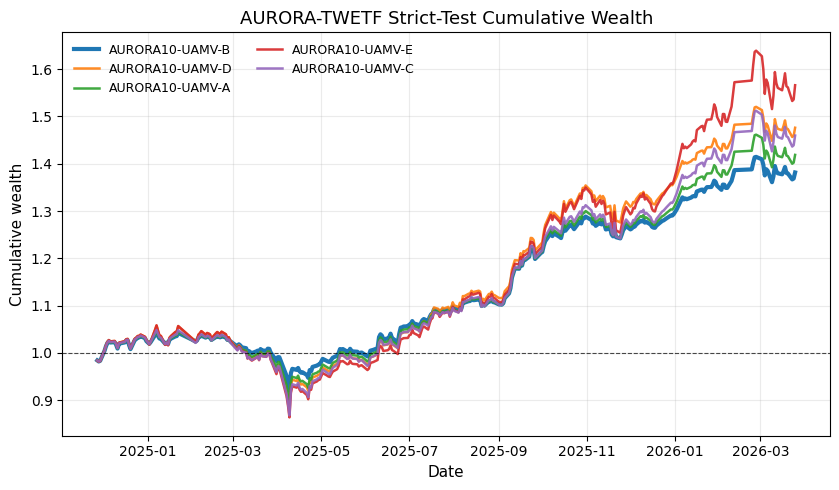

Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/uncertainty_aware_mean_variance_allocation/run_20260624_100748/paper_figures/figure_6_3_aurora_uamv_cumulative_wealth.png
Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/uncertainty_aware_mean_variance_allocation/run_20260624_100748/paper_figures/figure_6_3_aurora_uamv_cumulative_wealth.pdf


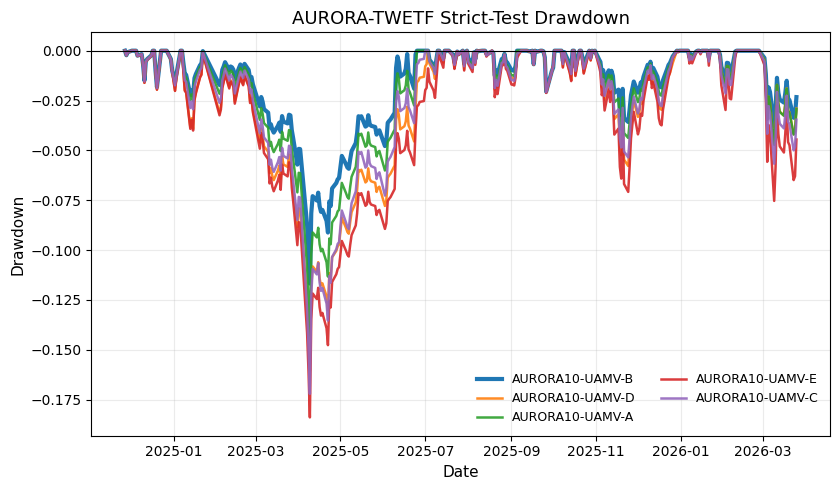

Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/uncertainty_aware_mean_variance_allocation/run_20260624_100748/paper_figures/figure_6_4_aurora_uamv_drawdown.png
Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/uncertainty_aware_mean_variance_allocation/run_20260624_100748/paper_figures/figure_6_4_aurora_uamv_drawdown.pdf

Summary check:


,strategy,n_days,start_date,end_date,total_return_check,max_drawdown_check
0,AURORA10-UAMV-B,319,2024-11-27,2026-03-25,0.381520,-0.116788
1,AURORA10-UAMV-D,319,2024-11-27,2026-03-25,0.476056,-0.160498
2,AURORA10-UAMV-A,319,2024-11-27,2026-03-25,0.418661,-0.144723
3,AURORA10-UAMV-E,319,2024-11-27,2026-03-25,0.565929,-0.183928
4,AURORA10-UAMV-C,319,2024-11-27,2026-03-25,0.459515,-0.172110



Exported plotted data:
/content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/uncertainty_aware_mean_variance_allocation/run_20260624_100748/paper_figures/figure_6_3_aurora_uamv_cumulative_wealth_data.csv
/content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/uncertainty_aware_mean_variance_allocation/run_20260624_100748/paper_figures/figure_6_4_aurora_uamv_drawdown_data.csv
/content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/uncertainty_aware_mean_variance_allocation/run_20260624_100748/paper_figures/figure_6_3_6_4_aurora_uamv_summary_check.csv


In [2]:
# =============================================================================
# Generate Figure 6.3 and Figure 6.4 for Section 6.4
# AURORA-TWETF UAMV allocation variants
#
# Correct version:
# Loads separate aggregate_test_returns_UAMV_*.parquet files and combines them.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 0. Colab setup
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Google Drive mount skipped or failed.")


# =============================================================================
# 1. Paths and configuration
# =============================================================================

RETURNS_DIR = Path(
    "/content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/"
    "uncertainty_aware_mean_variance_allocation/run_20260624_100748/returns"
)

OUT_DIR = Path(
    "/content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/"
    "uncertainty_aware_mean_variance_allocation/run_20260624_100748/paper_figures"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)

STRICT_START = "2024-11-27"
STRICT_END = "2026-03-25"

# Strategy files to load
STRATEGY_FILES = {
    "AURORA10-UAMV-B": "aggregate_test_returns_UAMV_B_more60_defensive.parquet",
    "AURORA10-UAMV-D": "aggregate_test_returns_UAMV_D_low_turnover.parquet",
    "AURORA10-UAMV-A": "aggregate_test_returns_UAMV_A_balanced.parquet",
    "AURORA10-UAMV-E": "aggregate_test_returns_UAMV_E_no_regime_tilt_control.parquet",
    "AURORA10-UAMV-C": "aggregate_test_returns_UAMV_C_more60_growth.parquet",
}


# =============================================================================
# 2. Load and combine UAMV return files
# =============================================================================

return_series = {}

for label, filename in STRATEGY_FILES.items():
    path = RETURNS_DIR / filename

    if not path.exists():
        raise FileNotFoundError(f"Missing file for {label}: {path}")

    df = pd.read_parquet(path)

    # The file already uses date as index in your output.
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    print(f"\nLoaded {label}")
    print("File:", filename)
    print("Shape:", df.shape)
    print("Date range:", df.index.min(), "to", df.index.max())
    print("Columns:", df.columns.tolist())

    # Use net returns for paper figures because they include transaction costs.
    if "net_return" not in df.columns:
        raise ValueError(f"'net_return' column not found in {filename}")

    return_series[label] = df["net_return"].copy()

# Combine into wide matrix
returns = pd.DataFrame(return_series).sort_index()

# Strict-test filter
returns = returns.loc[STRICT_START:STRICT_END].copy()

if returns.empty:
    raise ValueError("No rows found in the strict-test period.")

returns = returns.fillna(0.0)

print("\nCombined strict-test return matrix")
print("Shape:", returns.shape)
print("Date range:", returns.index.min(), "to", returns.index.max())
print("Columns:", returns.columns.tolist())
display(returns.head())


# =============================================================================
# 3. Compute cumulative wealth and drawdown
# =============================================================================

wealth = (1.0 + returns).cumprod()
drawdown = wealth / wealth.cummax() - 1.0


# =============================================================================
# 4. Figure 6.3: Cumulative wealth
# =============================================================================

plt.figure(figsize=(8.5, 5.0))

for col in wealth.columns:
    lw = 3.0 if col == "AURORA10-UAMV-B" else 1.8
    alpha = 1.0 if col == "AURORA10-UAMV-B" else 0.9

    plt.plot(
        wealth.index,
        wealth[col],
        label=col,
        linewidth=lw,
        alpha=alpha,
    )

plt.axhline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)
plt.title("AURORA-TWETF Strict-Test Cumulative Wealth", fontsize=13)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Cumulative wealth", fontsize=11)
plt.legend(frameon=False, ncol=2, fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout()

fig63_png = OUT_DIR / "figure_6_3_aurora_uamv_cumulative_wealth.png"
fig63_pdf = OUT_DIR / "figure_6_3_aurora_uamv_cumulative_wealth.pdf"

plt.savefig(fig63_png, dpi=300, bbox_inches="tight")
plt.savefig(fig63_pdf, bbox_inches="tight")
plt.show()

print("Saved:", fig63_png)
print("Saved:", fig63_pdf)


# =============================================================================
# 5. Figure 6.4: Drawdown
# =============================================================================

plt.figure(figsize=(8.5, 5.0))

for col in drawdown.columns:
    lw = 3.0 if col == "AURORA10-UAMV-B" else 1.8
    alpha = 1.0 if col == "AURORA10-UAMV-B" else 0.9

    plt.plot(
        drawdown.index,
        drawdown[col],
        label=col,
        linewidth=lw,
        alpha=alpha,
    )

plt.axhline(0.0, color="black", linewidth=0.8)
plt.title("AURORA-TWETF Strict-Test Drawdown", fontsize=13)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Drawdown", fontsize=11)
plt.legend(frameon=False, ncol=2, fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout()

fig64_png = OUT_DIR / "figure_6_4_aurora_uamv_drawdown.png"
fig64_pdf = OUT_DIR / "figure_6_4_aurora_uamv_drawdown.pdf"

plt.savefig(fig64_png, dpi=300, bbox_inches="tight")
plt.savefig(fig64_pdf, bbox_inches="tight")
plt.show()

print("Saved:", fig64_png)
print("Saved:", fig64_pdf)


# =============================================================================
# 6. Export plotted data and summary check
# =============================================================================

wealth_path = OUT_DIR / "figure_6_3_aurora_uamv_cumulative_wealth_data.csv"
drawdown_path = OUT_DIR / "figure_6_4_aurora_uamv_drawdown_data.csv"
summary_path = OUT_DIR / "figure_6_3_6_4_aurora_uamv_summary_check.csv"

wealth.to_csv(wealth_path)
drawdown.to_csv(drawdown_path)

summary_rows = []

for col in returns.columns:
    r = returns[col].fillna(0.0)
    w = (1.0 + r).cumprod()
    dd = w / w.cummax() - 1.0

    summary_rows.append({
        "strategy": col,
        "n_days": len(r),
        "start_date": r.index.min(),
        "end_date": r.index.max(),
        "total_return_check": w.iloc[-1] - 1.0,
        "max_drawdown_check": dd.min(),
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(summary_path, index=False)

print("\nSummary check:")
display(summary.round(6))

print("\nExported plotted data:")
print(wealth_path)
print(drawdown_path)
print(summary_path)